In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt


In [3]:
DATASET_PATH = "Train"


In [4]:
for class_name in os.listdir(DATASET_PATH):
    class_path = os.path.join(DATASET_PATH, class_name)
    print(class_name, ":", len(os.listdir(class_path)))


acne : 840
eczema : 1235
pigmentation : 568


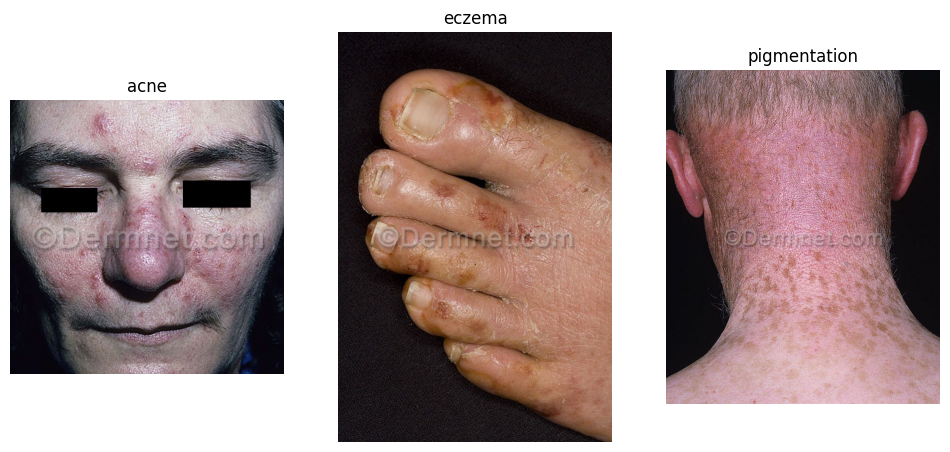

In [15]:
import random

plt.figure(figsize=(12,6))

for i, class_name in enumerate(os.listdir(DATASET_PATH)):
    class_path = os.path.join(DATASET_PATH, class_name)
    img_name = random.choice(os.listdir(class_path))
    img_path = os.path.join(class_path, img_name)
    
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    plt.subplot(1,3,i+1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis("off")

plt.show()


In [19]:
img.shape


(720, 590, 3)

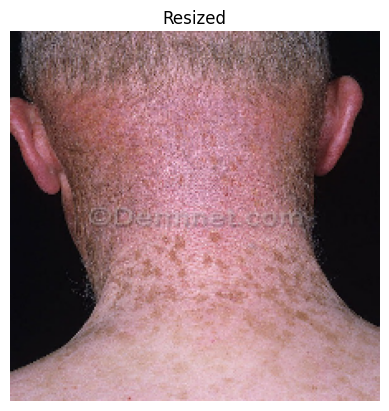

In [23]:
IMG_SIZE = 224

img_resized = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

plt.imshow(img_resized)
plt.title("Resized")
plt.axis("off")
plt.show()


In [24]:
img_resized.shape


(224, 224, 3)

In [25]:
img_normalized = img_resized / 255.0


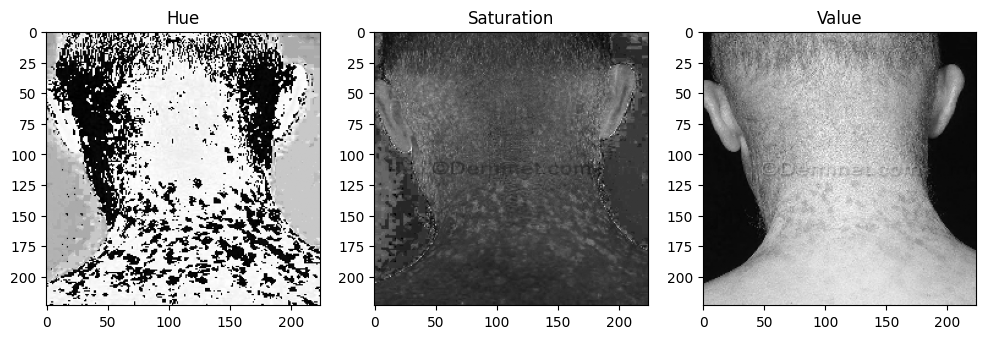

In [26]:
img_hsv = cv2.cvtColor(img_resized, cv2.COLOR_RGB2HSV)

h, s, v = cv2.split(img_hsv)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(h, cmap='gray')
plt.title("Hue")

plt.subplot(1,3,2)
plt.imshow(s, cmap='gray')
plt.title("Saturation")

plt.subplot(1,3,3)
plt.imshow(v, cmap='gray')
plt.title("Value")

plt.show()


In [27]:
img_normalized = img_resized / 255.0

print("Min pixel:", img_normalized.min())
print("Max pixel:", img_normalized.max())


Min pixel: 0.0
Max pixel: 0.996078431372549


In [28]:
shapes = []

for class_name in os.listdir(DATASET_PATH):
    class_path = os.path.join(DATASET_PATH, class_name)
    
    for img_name in os.listdir(class_path)[:5]:  # only 5 per class
        img_path = os.path.join(class_path, img_name)
        img = cv2.imread(img_path)
        
        if len(img.shape) == 2:
            img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
        else:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        shapes.append(img.shape)

print(shapes)


[(472, 720, 3), (472, 720, 3), (472, 720, 3), (472, 720, 3), (472, 720, 3), (472, 720, 3), (472, 720, 3), (472, 720, 3), (472, 720, 3), (472, 720, 3), (463, 720, 3), (480, 720, 3), (472, 720, 3), (720, 472, 3), (472, 720, 3)]


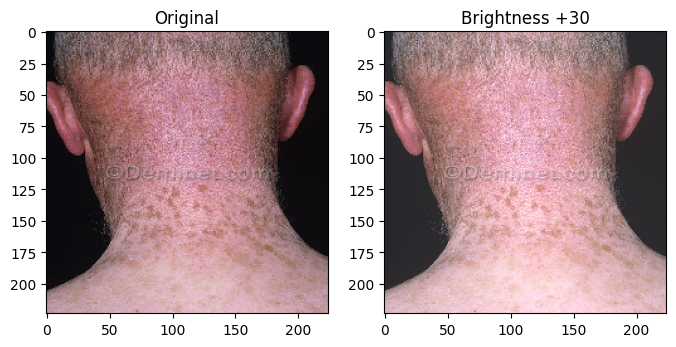

In [30]:
bright = cv2.convertScaleAbs(img_resized, alpha=1.0, beta=30)

plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.imshow(img_resized)
plt.title("Original")

plt.subplot(1,2,2)
plt.imshow(bright)
plt.title("Brightness +30")

plt.show()


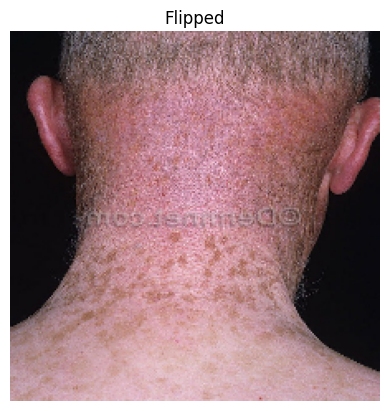

In [31]:
flip = cv2.flip(img_resized, 1)

plt.imshow(flip)
plt.title("Flipped")
plt.axis("off")
plt.show()
